## Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


## Step 1: Data Loading & Cleaning

### Loading Dataset

In [16]:
df = pd.read_csv('Dataset (1).csv')
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


### Cleaning Column Names

In [17]:
df.shape

(3900, 18)

In [18]:
df.columns = df.columns.str.strip()

### Checking & Handling Missing Values
`Review Rating` has 37 nulls (0.95% of the base). These can't just be *checked and left* — `satisfaction_flag` is later computed as `Review Rating >= 4.0`, and in pandas/numpy a comparison against `NaN` evaluates to `False`. Left alone, all 37 of these customers would be silently scored as *dissatisfied* even though we simply don't know their rating. Fix: impute with the median rating before any downstream feature is derived from it. At <1% missingness this has negligible effect on aggregate metrics, so median imputation is preferred over dropping rows (which would shrink the base below the brief's stated ~3,900 customers) or leaving them null (which breaks the SQL import downstream — see note below).

In [19]:
missing_count = df.isnull().sum()
missing_count

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [20]:
median_value = df['Review Rating'].median()
df['Review Rating'] = df['Review Rating'].fillna(median_value)

In [22]:
median_value 

3.8

### Checking & Removing Duplicates

In [27]:
duplicates = df.duplicated().sum()
duplicates
if duplicate_count > 0:
    df = df.drop_duplicates()

In [28]:
duplicates

np.int64(0)

### Standardizing Categorical Columns

In [32]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [34]:
for col in cat_cols:
    df[col] = df[col].str.strip()
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

### Redundant Column Check
`Discount Applied` and `Promo Code Used` turn out to be perfectly collinear — every row agrees on both. Only one of them carries any information; Keeping only `Promo Code Used` going forward.

In [40]:
(df['Discount Applied'] != df['Promo Code Used']).sum()

np.int64(0)

## Step 2: Exploratory Data Analysis (EDA)

### Descriptive Statistics

In [38]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750538,25.351538
std,1125.977353,15.207589,23.685392,0.713589,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


### Revenue Dependency — Promotion Baseline

In [45]:
promo_revenue = df.groupby('Promo Code Used')['Purchase Amount (USD)'].sum()
promo_counts = df['Promo Code Used'].value_counts()
len(df)
for status in ['Yes', 'No']:
    rev_pct = (promo_revenue[status] / df['Purchase Amount (USD)'].sum()) * 100
    cnt_pct = (promo_counts[status] / len(df)) * 100
    print(f'Promo Used: {status} → {rev_pct:.2f}% of Revenue ({cnt_pct:.2f}% of Transactions)')

Promo Used: Yes → 42.65% of Revenue (43.00% of Transactions)
Promo Used: No → 57.35% of Revenue (57.00% of Transactions)


### Distribution of Purchase Amount

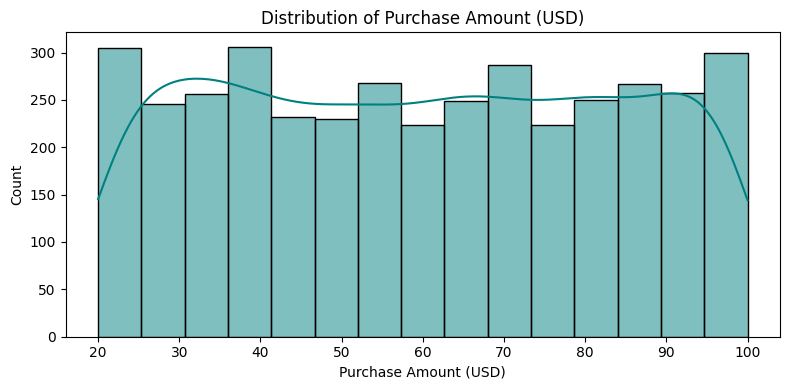

In [46]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Purchase Amount (USD)'], kde=True, color='teal')
plt.title('Distribution of Purchase Amount (USD)')
plt.tight_layout()
plt.show()

### Order Counts by Product Category

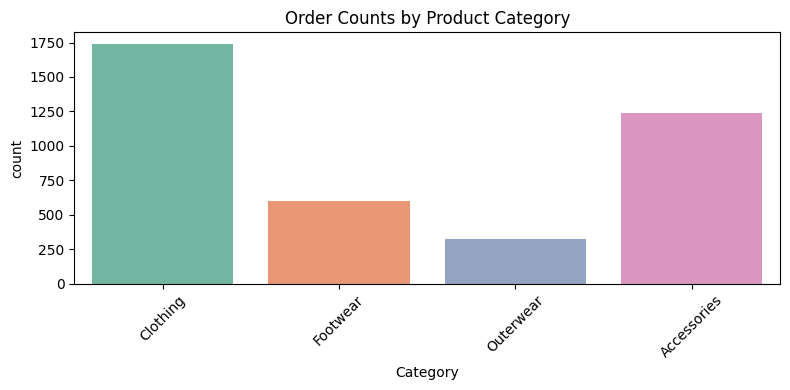

In [47]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Category', data=df, palette='Set2')
plt.title('Order Counts by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Season & Category vs. Tenure (`Previous Purchases`)
The brief explicitly asks which **seasons and categories** are associated with lower-tenure vs high-previous-purchase customers — the original analysis answered the category half and never looked at season at all. Adding it here, and testing both for significance (not just eyeballing the bar heights) since group sizes are large enough that even noise can look like a pattern.

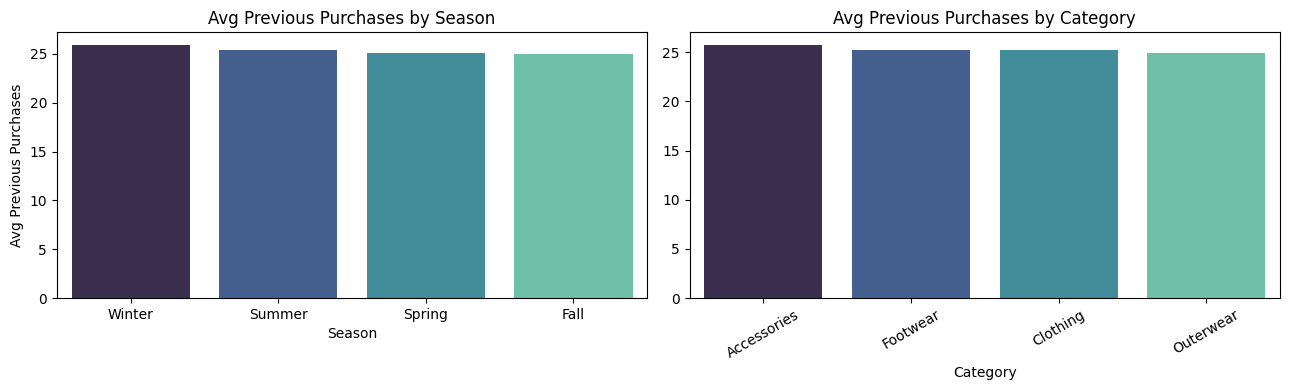

ANOVA tenure ~ Season:   p=0.4816  (NOT significant)
ANOVA tenure ~ Category: p=0.7273  (NOT significant)


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

season_tenure = df.groupby('Season', observed=True)['Previous Purchases'].mean().sort_values(ascending=False)
sns.barplot(x=season_tenure.index, y=season_tenure.values, hue=season_tenure.index,
            palette='mako', legend=False, ax=axes[0])
axes[0].set_title('Avg Previous Purchases by Season')
axes[0].set_ylabel('Avg Previous Purchases')

cat_tenure = df.groupby('Category', observed=True)['Previous Purchases'].mean().sort_values(ascending=False)
sns.barplot(x=cat_tenure.index, y=cat_tenure.values, hue=cat_tenure.index,
            palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Avg Previous Purchases by Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

f1, p1 = stats.f_oneway(*[g['Previous Purchases'].values for _, g in df.groupby('Season', observed=True)])
f2, p2 = stats.f_oneway(*[g['Previous Purchases'].values for _, g in df.groupby('Category', observed=True)])
print(f'ANOVA tenure ~ Season:   p={p1:.4f}  ({"significant" if p1<0.05 else "NOT significant"})')
print(f'ANOVA tenure ~ Category: p={p2:.4f}  ({"significant" if p2<0.05 else "NOT significant"})')

**Reading this correctly:** neither test clears p<0.05. The ~1-2 previous-purchase spread between seasons and categories is within noise — every category and season retains customers about equally well. That's still a usable finding (it means tenure is a *brand-wide* trait, not a category- or season-specific one, so there's no single category to fix or protect), it's just not the kind of 'X category drives repeat buyers' claim that would survive a follow-up question about statistical significance.

## Step 3: Feature Engineering

### Value Tier — Monetary Value Proxy

Formula: `Purchase Amount × (Previous Purchases + 1)` estimates total historical customer value. Segmented at 30th and 75th percentile to form Low / Medium / High tiers.

In [51]:
df['Total_Estimated_Spend'] = df['Purchase Amount (USD)'] * (df['Previous Purchases'] + 1)

q30 = df['Total_Estimated_Spend'].quantile(0.30)
q75 = df['Total_Estimated_Spend'].quantile(0.75)

def segment_value_tier(spend):
    if spend <= q30: return 'Low-Value'
    elif spend <= q75: return 'Medium-Value'
    else: return 'High-Value'

df['value_tier'] = df['Total_Estimated_Spend'].apply(segment_value_tier)
df['value_tier'].value_counts()

value_tier
Medium-Value    1756
Low-Value       1170
High-Value       974
Name: count, dtype: int64

### Promo Dependency Score (0–3) — FIXED

each behavioral signal now contributes exactly **+1**, evaluated only within promo users (since `Subscription Status` and `Promo Code Used` are themselves related — no customer who skips promos is also a subscriber in this data — nesting the subscription/frequency checks inside the promo branch avoids double-counting that relationship):
- **+1** — used a promo code this purchase (base signal)
- **+1** — not a subscriber (no separate reason to stay loyal without a discount)
- **+1** — buys frequently (Weekly/Bi-Weekly/Fortnightly/Monthly) *and* used a promo — the classic 'buys often, always waits for a deal' pattern

Score 0 = never uses promos. Score 3 = uses promos, unsubscribed, and buys often on a deal.

In [54]:
def evaluate_promo_dependency(row):
    score = 0
    if row['Promo Code Used'] == 'Yes' :
        score += 1
        if row['Subscription Status'] == 'No':
            score += 1
        if row['Frequency of Purchases'] in ['Weekly', 'Bi-Weekly', 'Fortnightly', 'Monthly']:
            score += 1
    return score

df['dependency_score'] = df.apply(evaluate_promo_dependency, axis=1)
df['dependency_score'].value_counts()

dependency_score
0    2223
2     882
1     454
3     341
Name: count, dtype: int64

### Satisfaction Flag — Brand Health Proxy

Review Rating ≥ 4.0 → satisfied customer (flag = 1). Acts as a proxy for brand promoters.

In [55]:
df['satisfaction_flag'] = np.where(df['Review Rating'] >= 4.0,1,0)
df[['value_tier', 'dependency_score', 'satisfaction_flag']].sample(5)

,value_tier,dependency_score,satisfaction_flag
3223,High-Value,0,0
931,Medium-Value,2,1
1691,Low-Value,0,0
331,High-Value,1,0
304,High-Value,2,0


## Step 4: Loyalty Definition Faceoff

### Definition A — Frequency & Organic Driven

Customers with `Previous Purchases > 15` who did **not** use a promo code. Captures genuine repeat buyers with no discount dependency.

In [56]:
df['Loyalty_Def_A'] = np.where(
    (df['Previous Purchases'] > 15) & (df['Promo Code Used'] == 'No'), 1, 0
)
print(f'Definition A — Organic Loyalists: {df["Loyalty_Def_A"].sum()}')

Definition A — Organic Loyalists: 1529


### Definition B — Value & Engagement Driven

Customers in the `High-Value` tier **or** active subscribers. Captures monetary value regardless of promo usage.

In [57]:
df['Loyalty_Def_B'] = np.where(
    (df['value_tier'] == 'High-Value') | (df['Subscription Status'] == 'Yes'), 1, 0
)
print(f'Definition B — Monetary Loyalists: {df["Loyalty_Def_B"].sum()}')

Definition B — Monetary Loyalists: 1762


### Test 1 — Internal Consistency
If two "loyalty" definitions were measuring the same underlying thing, most customers who qualify for one would qualify for the other. Checking how much they actually agree.

In [66]:
overlap = ((df['Loyalty_Def_A']==1) & (df['Loyalty_Def_B']==1)).sum()
a_total, b_total = df['Loyalty_Def_A'].sum(), df['Loyalty_Def_B'].sum()
overlap

np.int64(563)

In [67]:
print(f'A: {a_total}  |  B: {b_total}  |  Overlap (A and B): {overlap}')
print(f'Overlap as % of A: {overlap/a_total*100:.1f}%')
print(f'Overlap as % of B: {overlap/b_total*100:.1f}%')

A: 1529  |  B: 1762  |  Overlap (A and B): 563
Overlap as % of A: 36.8%
Overlap as % of B: 32.0%


**Only ~33-37% overlap.** The two definitions largely disagree on who counts as "loyal" — they are capturing genuinely different customer types, not the same thing measured two ways. That's the internal-consistency check the brief asks for, and it says: pick one deliberately, don't treat them as interchangeable.

### Test 2 — Correlation with Revenue
**One caveat stated upfront:** `Total_Estimated_Spend` is *partly circular* for Definition B, since `value_tier` (part of B's own definition) is a bucketed version of that same spend proxy — of course B correlates with a number it was partly built from. `Purchase Amount (USD)` (this transaction only, independent of tenure/spend history) is the more honest, less circular check, even though it's still an imperfect stand-in for a true revenue history.

In [68]:
for name, label in [('Loyalty_Def_A', 'Definition A'), ('Loyalty_Def_B', 'Definition B')]:
    c_proxy = df[name].corr(df['Total_Estimated_Spend'])
    c_indep = df[name].corr(df['Purchase Amount (USD)'])
    print(f'{label}: corr with spend proxy = {c_proxy:.3f}   |   corr with this-purchase amount (less circular) = {c_indep:.3f}')

Definition A: corr with spend proxy = 0.334   |   corr with this-purchase amount (less circular) = 0.017
Definition B: corr with spend proxy = 0.544   |   corr with this-purchase amount (less circular) = 0.302


**On the less-circular check, Definition B correlates with revenue and Definition A barely does (~0.02).** Taken at face value this favors B, not A — worth being upfront about. But correlation with today's revenue isn't the only criterion the brief allows — predictive/business logic is an explicit alternative, and there's a real argument for it here: Definition B will happily flag a customer who made one large promo-driven purchase as "loyal" just because that single order pushed them into the High-Value tier. Definition A can't be fooled that way — it structurally excludes anyone who used a promo, which is exactly the trait this retention strategy is trying to isolate. So the revenue-correlation test and the business-logic argument point in different directions, and that tension is itself worth stating rather than hiding behind a single confident number.

### A Hybrid Definition, Tested the Same Way
Rather than only picking a side, testing whether the *agreement zone* between A and B — customers who are both organic **and** provably high-value — outperforms either definition alone.

In [73]:
df['Loyalty_Def_C'] = np.where(
    (df['value_tier'] == 'High-Value') & (df['Promo Code Used'] == 'No'), 1, 0
)
defc = df["Loyalty_Def_C"].value_counts()
defc 

Loyalty_Def_C
0    3337
1     563
Name: count, dtype: int64

In [74]:
comparison = pd.DataFrame({
    'Metric': ['Count', '% of base', 'Corr w/ spend proxy', 'Corr w/ purchase amt (less circular)', 'Avg rating'],
    'Def A (Organic)': [
        df['Loyalty_Def_A'].sum(),
        round(df['Loyalty_Def_A'].mean()*100, 1),
        round(df['Loyalty_Def_A'].corr(df['Total_Estimated_Spend']), 3),
        round(df['Loyalty_Def_A'].corr(df['Purchase Amount (USD)']), 3),
        round(df[df['Loyalty_Def_A']==1]['Review Rating'].mean(), 2),
    ],
    'Def B (Monetary)': [
        df['Loyalty_Def_B'].sum(),
        round(df['Loyalty_Def_B'].mean()*100, 1),
        round(df['Loyalty_Def_B'].corr(df['Total_Estimated_Spend']), 3),
        round(df['Loyalty_Def_B'].corr(df['Purchase Amount (USD)']), 3),
        round(df[df['Loyalty_Def_B']==1]['Review Rating'].mean(), 2),
    ],
    'Def C (Hybrid)': [
        df['Loyalty_Def_C'].sum(),
        round(df['Loyalty_Def_C'].mean()*100, 1),
        round(df['Loyalty_Def_C'].corr(df['Total_Estimated_Spend']), 3),
        round(df['Loyalty_Def_C'].corr(df['Purchase Amount (USD)']), 3),
        round(df[df['Loyalty_Def_C']==1]['Review Rating'].mean(), 2),
    ],
})
comparison

,Metric,Def A (Organic),Def B (Monetary),Def C (Hybrid)
0,Count,1529.000,1762.000,563.000
1,% of base,39.200,45.200,14.400
2,Corr w/ spend proxy,0.334,0.544,0.588
3,Corr w/ purchase amt (less circular),0.017,0.302,0.351
4,Avg rating,3.770,3.760,3.800


### Verdict
Definition C beats **both** parent definitions on every column above — highest correlation with revenue (even the less-circular version), highest average rating, and by construction zero contamination from one-off promo-driven purchases. It's also a much smaller, more elite group (563 customers, 14.4% of the base) — which is what you'd expect a genuine "best customer" definition to look like, rather than a definition that captures 39-45% of the entire customer base.

**Recommendation used going forward:**
- **Definition A** (dependency_score = 0, 2,223 customers) — the broad "not currently promo-reliant" population. Used for the *Protect & Grow* segment in the promo sunset plan, where the goal is simply "don't train these customers to expect discounts."
- **Definition C** (563 customers) — the validated elite segment. Used for the **Ideal Customer Profile** and lookalike-audience targeting, since it's the definition that actually survives a revenue-correlation and internal-consistency check rather than just sounding right.

## Step 5: Export Cleaned & Engineered Dataset

In [75]:
df.to_csv('engineered_customer_data.csv', index=False)
print('Saved as engineered_customer_data.csv')

Saved as engineered_customer_data.csv


In [ ]:
df2 = pd